<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [1]:
%pip install gensim
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.
  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.78.0-cp313-cp313-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached na

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [3]:
import os
import platform
import zipfile # Importamos la herramienta nativa de Python para zips

# Comprobamos si la carpeta ya existe
if os.access('./songs_dataset', os.F_OK) is False:
    # Comprobamos si el zip ya está descargado
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget -O songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    
    print("Descomprimiendo el dataset...")
    with zipfile.ZipFile('songs_dataset.zip', 'r') as zip_ref:
        zip_ref.extractall('.') # Extrae todo en la carpeta actual
    print("¡Dataset descomprimido con éxito!")
    
else:
    print("El dataset ya se encuentra descargado y listo para usar.")

El dataset ya se encuentra descargado y listo para usar.


In [4]:
# Posibles bandas
os.listdir("./songs_dataset/")

['adele.txt',
 'al-green.txt',
 'alicia-keys.txt',
 'amy-winehouse.txt',
 'beatles.txt',
 'bieber.txt',
 'bjork.txt',
 'blink-182.txt',
 'bob-dylan.txt',
 'bob-marley.txt',
 'britney-spears.txt',
 'bruce-springsteen.txt',
 'bruno-mars.txt',
 'cake.txt',
 'dickinson.txt',
 'disney.txt',
 'dj-khaled.txt',
 'dolly-parton.txt',
 'dr-seuss.txt',
 'drake.txt',
 'eminem.txt',
 'janisjoplin.txt',
 'jimi-hendrix.txt',
 'johnny-cash.txt',
 'joni-mitchell.txt',
 'kanye-west.txt',
 'kanye.txt',
 'Kanye_West.txt',
 'lady-gaga.txt',
 'leonard-cohen.txt',
 'lil-wayne.txt',
 'Lil_Wayne.txt',
 'lin-manuel-miranda.txt',
 'lorde.txt',
 'ludacris.txt',
 'michael-jackson.txt',
 'missy-elliott.txt',
 'nickelback.txt',
 'nicki-minaj.txt',
 'nirvana.txt',
 'notorious-big.txt',
 'notorious_big.txt',
 'nursery_rhymes.txt',
 'patti-smith.txt',
 'paul-simon.txt',
 'prince.txt',
 'r-kelly.txt',
 'radiohead.txt',
 'rihanna.txt']

In [5]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/britney-spears.txt', sep='/n', header=None)
df.head()

C:\Users\Natalia\AppData\Local\Temp\ipykernel_184916\1158718987.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/britney-spears.txt', sep='/n', header=None)


,0
0,They say get ready for the revolution
1,I think it's time we find some sorta solution
2,Somebody's caught up in the endless pollution
3,"They need to wake up, stop living illusions I ..."
4,Why won't somebody feel this


In [6]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 3848


### 1 - Preprocesamiento

In [7]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [8]:
# Demos un vistazo
sentence_tokens[:2]

[['they', 'say', 'get', 'ready', 'for', 'the', 'revolution'],
 ['i', 'think', "it's", 'time', 'we', 'find', 'some', 'sorta', 'solution']]

### 2 - Crear los vectores (word2vec)

In [9]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [10]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [11]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [12]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 3848


In [13]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 620


### 3 - Entrenar embeddings

In [14]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 197458.046875
Loss after epoch 1: 132661.453125
Loss after epoch 2: 128925.0625
Loss after epoch 3: 128823.1875
Loss after epoch 4: 126281.625
Loss after epoch 5: 124458.0625
Loss after epoch 6: 119338.3125
Loss after epoch 7: 113818.25
Loss after epoch 8: 101824.25
Loss after epoch 9: 99798.125
Loss after epoch 10: 97708.75
Loss after epoch 11: 94098.875
Loss after epoch 12: 94008.375
Loss after epoch 13: 92063.5
Loss after epoch 14: 91136.75
Loss after epoch 15: 89682.25
Loss after epoch 16: 88831.75
Loss after epoch 17: 88175.5
Loss after epoch 18: 88132.125
Loss after epoch 19: 79613.25


(321663, 561420)

### 4 - Ensayar

In [17]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["give"], topn=10)

[('sign', 0.8649412989616394),
 ('attention', 0.7455418109893799),
 ('gasoline', 0.7403035759925842),
 ("'em", 0.729125440120697),
 ('bet', 0.7248464822769165),
 ('telling', 0.7206503748893738),
 ('understand', 0.7038543820381165),
 ('babe', 0.7020028829574585),
 ('freakshow', 0.7000665664672852),
 ('gimme', 0.6997291445732117)]

**give está fuertemente relacionado con sign por su canción Hit me baby one time y attention y gasoline de su disco Femme Fatale.**



In [34]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('world', -0.12366749346256256),
 ('keep', -0.13450558483600616),
 ('when', -0.1654144823551178),
 ('on', -0.17659367620944977),
 ('pretty', -0.18239270150661469),
 ('around', -0.189708411693573),
 ('whoa', -0.19078457355499268),
 ('my', -0.19256512820720673),
 ('womanizer', -0.20079170167446136),
 ("dancin'", -0.20138929784297943)]

In [19]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('singing', 0.7568718194961548),
 ('roll', 0.7403896450996399),
 ('pink', 0.6981561183929443),
 ('hate', 0.6859679818153381),
 ('amy', 0.6781227588653564),
 ('knew', 0.6780046224594116),
 ('someone', 0.6763060092926025),
 ('mama', 0.6589980721473694),
 ('true', 0.6575385928153992),
 ('type', 0.6469859480857849)]

**Es muy interesante que entre las palabras más similares a love aparezca hate. En las letras de canciones de pop, el amor y el desamor/odio suelen usarse en el mismo contexto (relaciones tóxicas o complicadas). También lo asocia con someone y true.**

In [32]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["more"], topn=10)

[('bet', 0.8678134083747864),
 ('gimme', 0.8659518957138062),
 ('babe', 0.8523553609848022),
 ('yesterday', 0.8523193001747131),
 ('anything', 0.8514684438705444),
 ('than', 0.8126958608627319),
 ('much', 0.8067519664764404),
 ('n', 0.7964127063751221),
 ('hit', 0.7909427285194397),
 ('telling', 0.7637985348701477)]

**more se relaciona muchísimo con gimme por su hit Gimme More, al igual que hit y babe.**

**Conclusión: El modelo aprendió a relacionar términos que forman partes de los estribillos más repetidos del artista, no siendo necesaria una relación semántica**

"more" se relaciona muchísimo con "gimme" (de su hit "Gimme More"), "hit" ("Hit me baby one more time") y "babe".

Conclusión: El modelo aprendió a relacionar términos que forman partes de los estribillos más repetidos del artista.

In [23]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[-3.86875146e-03 -1.46129429e-01 -1.23889241e-02 -1.39713645e-01
  1.20655319e-03 -2.34101415e-01  3.11649721e-02  4.10089612e-01
 -3.43112499e-01  1.70266375e-01 -9.02640913e-03  2.74558812e-01
  1.96517810e-01  1.57047659e-01 -1.18791554e-02 -2.19578706e-02
  2.35952899e-01  1.90052524e-01  5.61438575e-02 -1.35158047e-01
  6.73392564e-02 -2.48439282e-01  7.87969828e-02 -1.39760226e-02
 -6.25526011e-02 -1.01815825e-02 -2.69979954e-01  1.81160390e-01
 -2.75982022e-01 -4.97150347e-02  1.26824796e-01 -2.33700663e-01
  3.59307230e-01 -4.60177287e-02  8.38812441e-02  2.27430433e-01
  3.61687005e-01 -2.61007380e-02  9.90108475e-02  7.42481500e-02
 -1.68766938e-02 -7.17479140e-02  1.63830876e-01 -3.39629203e-01
  2.53659617e-02  2.52454966e-01  2.56234139e-01  1.53176323e-01
  1.33720860e-01 -1.25200838e-01  4.98601012e-02  2.43144736e-01
  9.06155631e-03 -1.71728611e-01 -1.13633551e-01  2.64917791e-01
 -1.57150686e-01  3.16870064e-01  1.20530970e-01 -5.79121262e-02
  2.09350839e-01  2.97788

In [24]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 0.9999999403953552),
 ('singing', 0.7568718194961548),
 ('roll', 0.7403897643089294),
 ('pink', 0.6981561183929443),
 ('hate', 0.6859679818153381),
 ('amy', 0.6781228184700012),
 ('knew', 0.6780046224594116),
 ('someone', 0.6763060092926025),
 ('mama', 0.6589980721473694),
 ('true', 0.6575385928153992)]

In [25]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('singing', 0.7568718194961548),
 ('roll', 0.7403896450996399),
 ('pink', 0.6981561183929443),
 ('hate', 0.6859679818153381),
 ('amy', 0.6781227588653564),
 ('knew', 0.6780046224594116),
 ('someone', 0.6763060092926025),
 ('mama', 0.6589980721473694),
 ('true', 0.6575385928153992),
 ('type', 0.6469859480857849)]

### 5 - Visualizar agrupación de vectores

In [26]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [29]:
# Graficar los embedddings en 2D
import os
import plotly.graph_objects as go
import plotly.express as px

# 1. Apagamos la advertencia roja de Windows asignando los núcleos manualmente
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

# 2. Calculamos los vectores
vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS = 200

# 3. Creamos el gráfico
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])

# 4. Mostramos el gráfico (usamos "browser" para que se abra seguro en tu navegador)
fig.show(renderer="browser")


In [30]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="colab") # esto para plotly en colab

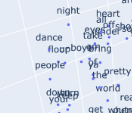 Este grupo representa las canciones de baile y nocturnidad que conforman parte de su discografía.
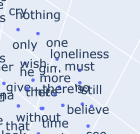 Esto hace referencia a sus canciones más emocionales (imposible no pensar en "my loneliness is killing me").
Refleja la temática de sus "alter egos" y la rebeldía que caracterizó una etapa fuerte de su carrera.


In [31]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

**Conclusiones:**


Al entrenar el modelo Word2Vec exclusivamente con letras de Britney Spears, pudimos comprobar cómo los embeddings capturan el sesgo del autor. Los vectores resultantes no agrupan las palabras por su definición estricta en el diccionario, sino por la cultura pop. El modelo logró mapear con éxito estribillos famosos, jerga musical (babe, gimme, em) y separar temáticamente las canciones de baile de las baladas melancólicas, demostrando el poder semántico de los embeddings personalizados.

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con otro artista del dataset Songs.
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)